# LASSO Model: Weekly Stock Market Data Analysis

### Reference: http://www.science.smith.edu/~jcrouser/SDS293/labs/lab10-py.html

### Step 1 - Loading the Required Libraries and Modules¶

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import scale 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
from sklearn import metrics

from time import time

from sklearn import linear_model
from sklearn import datasets
from sklearn.svm import l1_min_c

### Step 2 - Reading the Data and Performing Basic Data Checks and Preparing the data

In [2]:
#read  data
Weekly = pd.read_csv('H:\My Documents\TEACHING\Financial_Data_Analytics\MS_FINANCE_REVISED\DATA\Weekly.csv')

In [3]:
Weekly.head()

,Unnamed: 0,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,2,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,3,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,4,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,5,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [4]:
Weekly.tail()

,Unnamed: 0,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
1084,1085,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,1086,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,1087,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,1088,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up
1088,1089,2010,1.034,0.283,1.281,2.969,-0.861,2.707105,0.069,Up


In [5]:
#Checking the number of rows and columns
Weekly.shape


(1089, 10)

In [6]:
df = Weekly.drop(Weekly.columns[0], axis=1)
df.info()
dummies = pd.get_dummies(df[['Direction']])

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB


(1089, 9)

In [7]:
print(type(df)) 

<class 'pandas.core.frame.DataFrame'>


In [8]:
print(type(dummies)) 

<class 'pandas.core.frame.DataFrame'>


In [9]:
dummies.head()

,Direction_Down,Direction_Up
0,1,0
1,1,0
2,0,1
3,0,1
4,0,1


In [10]:
df.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


### Creating Dummy Variables for the Categorical Variables

In [11]:
y = dummies['Direction_Up']
# Drop the column with the independent variable (Salary), and columns for which we created dummy variables
X = df.drop(['Direction', 'Year', 'Today', 'Volume'], axis = 1).astype('float64')

# Define the feature set X.
#X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis = 1)
 
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Lag1    1089 non-null   float64
 1   Lag2    1089 non-null   float64
 2   Lag3    1089 non-null   float64
 3   Lag4    1089 non-null   float64
 4   Lag5    1089 non-null   float64
dtypes: float64(5)
memory usage: 42.7 KB


In [12]:
print(type(y)) 
y.head()

<class 'pandas.core.series.Series'>


0    0
1    0
2    1
3    1
4    1
Name: Direction_Up, dtype: uint8

### Step 3: Creating the Tuning Paramter: 
 In case of LogisticRegression, C is a hyper-parameter which describes the inverse of regularization strength. The higher the C, the less regularization is applied on the training. C=1/λ.
https://stackoverflow.com/questions/51830558/does-sklearn-logisticregressioncv-use-all-data-for-final-model

In [13]:
cs = l1_min_c(X, y, loss='log') * np.logspace(0, 7, 16)
cs

array([9.82052982e-03, 2.87608413e-02, 8.42302815e-02, 2.46680556e-01,
       7.22439669e-01, 2.11576901e+00, 6.19633542e+00, 1.81468640e+01,
       5.31457147e+01, 1.55644909e+02, 4.55828615e+02, 1.33496000e+03,
       3.90962334e+03, 1.14498971e+04, 3.35326790e+04, 9.82052982e+04])

### Step 4: Lasso coefficients with different value of C(1/lambda)
Associated with each C value is a vector of LASSO regression coefficients, which we'll store in a matrix coefs. In this case, it is a  16x5  matrix, with 16 rows (one for each C) and 5 columns (one for each predictors). 

#### REF: CHECK FOR LOGISTIC REG for REGULARIZATION: https://scikit-learn.org/stable/auto_examples/linear_model/plot_logistic_path.html#sphx-glr-auto-examples-linear-model-plot-logistic-path-py

In [14]:

lasso = linear_model.LogisticRegression(penalty='l1', solver='liblinear',
                                      tol=1e-6, max_iter=int(1e6),
                                      warm_start=True,
                                      intercept_scaling=10000.)




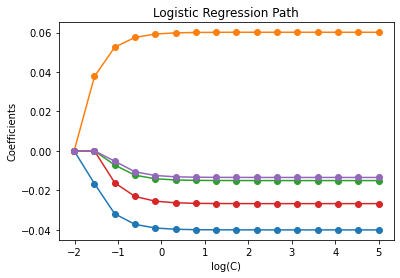

In [15]:
coefs_ = []
for c in  cs:
    lasso.set_params(C=c)
    lasso.fit(X, y)
    coefs_.append(lasso.coef_.ravel().copy())
#print("This took %0.3fs" % (time() - start))

coefs_ = np.array(coefs_)
plt.plot(np.log10(cs), coefs_, marker='o')
ymin, ymax = plt.ylim()
plt.xlabel('log(C)')
plt.ylabel('Coefficients')
plt.title('Logistic Regression Path')
plt.axis('tight')
plt.show()

In [16]:
np.shape(coefs_)
print(coefs_)

[[ 0.          0.          0.          0.          0.        ]
 [-0.01664537  0.03771496  0.          0.          0.        ]
 [-0.03194694  0.05259707 -0.0072179  -0.01622402 -0.00523421]
 [-0.03729412  0.05753644 -0.01235937 -0.02313963 -0.01064502]
 [-0.03913641  0.05925345 -0.014148   -0.02552642 -0.0125122 ]
 [-0.03976927  0.05984395 -0.01476166 -0.02634548 -0.01315452]
 [-0.03998527  0.06004589 -0.01497196 -0.02662532 -0.0133736 ]
 [-0.04005901  0.06011495 -0.01504386 -0.02672093 -0.01344849]
 [-0.04006671  0.06015535 -0.0150567  -0.0267479  -0.01345878]
 [-0.0400924   0.06014684 -0.01507642 -0.02676429 -0.01348242]
 [-0.04009563  0.06014971 -0.01507951 -0.02676798 -0.01348546]
 [-0.04009678  0.06015026 -0.01508061 -0.02676982 -0.01348676]
 [-0.04010025  0.06015532 -0.01507871 -0.02676188 -0.01349009]
 [-0.04009723  0.0601507  -0.01508108 -0.02677041 -0.01348724]
 [-0.04009722  0.06015075 -0.01508107 -0.02677047 -0.01348725]
 [-0.04009729  0.06015074 -0.01508113 -0.02677048 -0.01

Text(0, 0.5, 'weights')

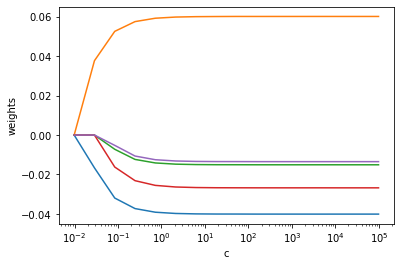

In [17]:
ax = plt.gca()
ax.plot(cs, coefs_)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('c')
plt.ylabel('weights')

#### Step 5: Cross validation

In [18]:
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html
from sklearn.linear_model import LogisticRegressionCV
clf = LogisticRegressionCV(cv=5, random_state=0).fit(X, y)
y_pred=clf.predict(X)
y_pred_proba=clf.predict_proba(X)
clf.score(X, y)

0.5555555555555556

In [19]:
y_pred_proba

array([[0.43811974, 0.56188026],
       [0.44078697, 0.55921303],
       [0.44088308, 0.55911692],
       ...,
       [0.43863606, 0.56136394],
       [0.44343619, 0.55656381],
       [0.44727572, 0.55272428]])

In [20]:
np.shape(clf.coef_)
clf.coef_

array([[-0.00547532,  0.00798849, -0.00243447, -0.00243745, -0.00195428]])

<AxesSubplot:>

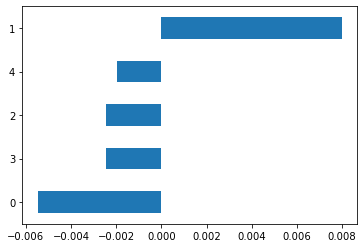

In [21]:
coefs1 = clf.coef_
coefs1_series = pd.Series(coefs1.ravel())
coefs1_series.sort_values().plot(kind="barh")

In [22]:
coefs1_series

0   -0.005475
1    0.007988
2   -0.002434
3   -0.002437
4   -0.001954
dtype: float64

### Stpe 5: Trainign and Test Data
We now split the samples into a training set and a test set in order to estimate the test error of the lasso:

In [23]:
# Split data into training and test sets
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

###  Step 6: Fit LASSO on Training Data and Evlauate on Test Data
Next we fit a LASSO regression model on the training set, and evaluate its MSE on the test set, using  λ=4 (arbitrary lambda) :

#### Csint or list of floats, default=10
Each of the values in Cs describes the inverse of regularization strength. If Cs is as an int, then a grid of Cs values are chosen in a logarithmic scale between 1e-4 and 1e4. Like in support vector machines, smaller values specify stronger regularization.
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html

In [24]:
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html
from sklearn.linear_model import LogisticRegressionCV
clf = LogisticRegressionCV(Cs=10,cv=5, random_state=0).fit(X_train, y_train)
y_pred=clf.predict(X_test)
y_pred_proba=clf.predict_proba(X_test)
clf.score(X_test, y_test) #Returns the score using the scoring option on the given test data and labels.

0.5376146788990825

#### scores_dict
dict with classes as the keys, and the values as the grid of scores obtained during cross-validating each fold,
Each dict value has shape (n_folds, n_cs or (n_folds, n_cs, n_l1_ratios)
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html

In [25]:
clf.scores_

{1: array([[0.57798165, 0.57798165, 0.56880734, 0.55963303, 0.55963303,
         0.55963303, 0.55963303, 0.55963303, 0.55963303, 0.55963303],
        [0.57798165, 0.57798165, 0.57798165, 0.57798165, 0.57798165,
         0.57798165, 0.57798165, 0.57798165, 0.57798165, 0.57798165],
        [0.56880734, 0.56880734, 0.56880734, 0.56880734, 0.56880734,
         0.56880734, 0.56880734, 0.56880734, 0.56880734, 0.56880734],
        [0.56880734, 0.56880734, 0.56880734, 0.56880734, 0.56880734,
         0.56880734, 0.56880734, 0.56880734, 0.56880734, 0.56880734],
        [0.57407407, 0.56481481, 0.5462963 , 0.52777778, 0.52777778,
         0.52777778, 0.52777778, 0.52777778, 0.52777778, 0.52777778]])}

#### coefs_paths_ndarray of shape (n_folds, n_cs, n_features) or (n_folds, n_cs, n_features + 1)
dict with classes as the keys, and the path of coefficients obtained during cross-validating across each fold and then across each Cs 
Here n_folds=5, n_cs=10, and n_features=5
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html

In [26]:
clf.coefs_paths_

{1: array([[[-2.98103915e-03,  1.89200781e-03, -1.41228311e-03,
          -1.01211443e-03, -2.01059596e-04,  2.92326781e-01],
         [-1.69899311e-02,  9.98591040e-03, -7.67263005e-03,
          -6.56236968e-03, -7.80726205e-04,  2.95558049e-01],
         [-4.42431360e-02,  2.22546422e-02, -1.80421375e-02,
          -2.01304307e-02, -1.21693248e-03,  3.03003282e-01],
         [-5.63611246e-02,  2.63814124e-02, -2.18271497e-02,
          -2.68942073e-02, -1.46979749e-03,  3.06720266e-01],
         [-5.84641791e-02,  2.70275303e-02, -2.24247648e-02,
          -2.80949201e-02, -1.52071303e-03,  3.07393701e-01],
         [-5.87430515e-02,  2.71092536e-02, -2.25057552e-02,
          -2.82584498e-02, -1.53176158e-03,  3.07414112e-01],
         [-5.87874635e-02,  2.71285658e-02, -2.25200427e-02,
          -2.82750192e-02, -1.53636487e-03,  3.07427592e-01],
         [-5.87860021e-02,  2.71182610e-02, -2.25141246e-02,
          -2.82842062e-02, -1.53221029e-03,  3.07440964e-01],
         [-5.

#### Cs_ndarray of shape (n_cs)
Array of C i.e. inverse of regularization parameter values used for cross-validation.

In [27]:
clf.Cs_

array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04])

#### C_ndarray of shape (n_classes,) or (n_classes - 1,)
Array of C that maps to the best scores across every class. If refit is set to False, then for each class, the best C is the average of the C’s that correspond to the best scores for each fold. C_ is of shape(n_classes,) when the problem is binary.
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html

In [28]:
clf.C_

array([0.0001])

#### classes_ndarray of shape (n_classes, )
A list of class labels known to the classifier.

In [29]:
clf.classes_

array([0, 1], dtype=uint8)

#### coef_ndarray of shape (1, n_features) or (n_classes, n_features)
Coefficient of the features in the decision function.

coef_ is of shape (1, n_features) when the given problem is binary.

<AxesSubplot:>

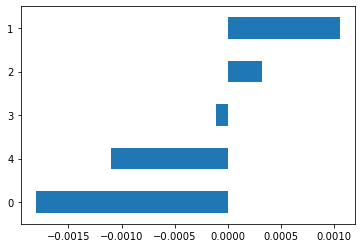

In [30]:
coefs1 = clf.coef_
coefs1_series = pd.Series(coefs1.ravel())
coefs1_series.sort_values().plot(kind="barh")

In [31]:
coefs1_series

0   -0.001807
1    0.001055
2    0.000320
3   -0.000115
4   -0.001101
dtype: float64

#### Check Logistic Regressions Coefficients: compare with Lasso Coefficients

In [32]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

print(lr.coef_)
print(lr.intercept_)

[[-0.03205575  0.01169838  0.0117046  -0.00586978 -0.01580304]]
[0.29958559]


### Confusion Matrix, Prediction Accuracy, Recall, and Precision of the LASSO Logistic Predicsions

In [34]:
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html
from sklearn.linear_model import LogisticRegressionCV
clf = LogisticRegressionCV(Cs=10,cv=5, random_state=0).fit(X_train, y_train)
y_pred=clf.predict(X_test)
y_pred_proba=clf.predict_proba(X_test)
clf.score(X_test, y_test) #Returns the score using the scoring option on the given test data and labels.

0.5376146788990825

In [35]:
confusion_matrix(y_test, y_pred)  

array([[  0, 252],
       [  0, 293]], dtype=int64)

#### The model preiction is up (1) for all observations. TP is 293, TN 0, FP 252, FN 0. Out of 545 total observation model is correct 293/545 = 53.76% of the time. Recall (which measures out of all positive classes how many are predcited correctly) is 100%. Specificity( that measures the proportion of actual negative (market down) that are correctly predicted =0/252=0%. SO the model performs very poorly in down market. An investor who is tryinng to reduce risk, would be subject to huge error (high risk) in down market. Precision (which measures out of all predicted positive (market up) classes how many are truly up market =293/545 =53.76% 

In [36]:
#REF: https://towardsdatascience.com/understanding-the-confusion-matrix-and-how-to-implement-it-in-python-319202e0fe4d
# Accuracy
from sklearn.metrics import accuracy_score
accuracy_score=accuracy_score(y_test, y_pred)
print(accuracy_score)
# Recall
from sklearn.metrics import recall_score
recall=recall_score(y_test, y_pred, average='binary')
print(recall)
# Precision
from sklearn.metrics import precision_score
precision=precision_score(y_test, y_pred, average='binary')
print(precision)

0.5376146788990825
1.0
0.5376146788990825


In [37]:
# Method 1: sklearn
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average='binary')

0.6992840095465394